In [1]:
import numpy as np
import pandas as pd
import os

from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import confusion_matrix

In [3]:
import optuna

/work/ka1176/caroline/gitlab/AI4EO-MapYourCity/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
root_dir = '/home/k/k202141/rootgit/AI4EO-MapYourCity/logs/evaluations/runs/'

In [5]:
train_set = pd.read_csv('../data/AI4EO-MapYourCity/v1/building-age-dataset/train/train-set.csv')
test_set = pd.read_csv('../data/AI4EO-MapYourCity/v1/building-age-dataset/test/test-set.csv')
test_set

,country_id,pid,city_id
0,PNN,eywttujal8,B2MVH
1,PNN,msagwwvcpf,B2MVH
2,PNN,cxywc79dxr,B2MVH
3,PNN,9kfydhmwko,B2MVH
4,PNN,d73djidnac,B2MVH
...,...,...,...
4524,QCD,buovk8byvb,YPGHW
4525,QCD,jswvnbhsdd,YPGHW
4526,QCD,kdsat5k9rh,YPGHW
4527,QCD,czecq3kzts,YPGHW


In [6]:
test_set['country_id'].value_counts()

country_id
QCD    2089
FMW    1428
PNN     934
HUN      78
Name: count, dtype: int64

In [7]:
class_prob = {}

for cid in train_set.country_id.unique():
    cdf = train_set.query('country_id == @cid')
    class_prob[cid] = cdf['label'].value_counts().index.values
    print(cid, cdf['label'].value_counts().index.values, cdf['label'].value_counts().values)

QCD [5 3 4 2 0 1 6] [1200 1198 1197 1197 1196 1193 1187]
PNN [0 4 1 5 2 6 3] [4132 1504 1462 1122 1001  410  358]
HUN [3 4 5 6 0 2 1] [641 592 578 399 253 251 116]
FMW [0 3 4 5 2 6 1] [2568 1447 1358  909  648  462  423]
EMA [0 2 1 3 4 6 5] [455 375 321 313  54  36  29]
NEA [4 5 6 3 2 1 0] [90 59 54 32 18  6  5]


In [8]:
class_prob

{'QCD': array([5, 3, 4, 2, 0, 1, 6]),
 'PNN': array([0, 4, 1, 5, 2, 6, 3]),
 'HUN': array([3, 4, 5, 6, 0, 2, 1]),
 'FMW': array([0, 3, 4, 5, 2, 6, 1]),
 'EMA': array([0, 2, 1, 3, 4, 6, 5]),
 'NEA': array([4, 5, 6, 3, 2, 1, 0])}

In [9]:
%%time
data_root = '/home/k/k202141/rootgit/AI4EO-MapYourCity/data/AI4EO-MapYourCity/v1/building-age-dataset/test/data/'
is_street = [os.path.exists(os.path.join(data_root, pid, 'street.jpg')) for pid in test_set.pid.values]

CPU times: user 42.1 ms, sys: 359 ms, total: 401 ms
Wall time: 24.3 s


In [10]:
test_set['is_street'] = is_street

In [11]:
for country_id in test_set.country_id.unique():
    country_df = test_set.query('country_id == @country_id')
    print(country_id, len(country_df))
    print(np.sum(country_df['is_street']))

PNN 934
0
HUN 78
78
FMW 1428
0
QCD 2089
2089


Best performing experiments on the dev set
---



|country_id | count | street | evaluation key | based on |dev set|
|---|---|---|---|---|---|
|QCD| 2089| yes |finetune_QCD_2| topview_streetview_05-27_A |0.7439|
|HUN| 78| yes |finetune_QCD_2| topview_streetview_05-27_A |0.3429|
|FMW| 1428| no |finetune_FMW|topmodal_swin_05-24_A|0.6483|
|PNN| 934| no |finetune_PNN|topmodal_swin_05-24_A |0.9159|


In [12]:
(2089*0.7135 + 78*0.36 + 1428*0.6483 + 934*0.9159)/(2089+78+1428+934)

0.7285945020975934

In [13]:
submission_df = test_set.drop(columns='is_street').copy()
submission_df = submission_df.sort_values('pid').reset_index().drop(columns='index')
submission_df

,country_id,pid,city_id
0,QCD,22mhjewvtj,YPGHW
1,QCD,22pujdqtiu,YPGHW
2,FMW,23ykackznc,7PNBD
3,QCD,2435ikdnmf,YPGHW
4,FMW,24akvvheae,7PNBD
...,...,...,...
4524,FMW,zz33egthkw,7PNBD
4525,PNN,zzfq447gpt,B2MVH
4526,QCD,zzijnoebwv,YPGHW
4527,QCD,zzphni4qma,YPGHW


In [25]:
expkeys = dict(QCD='finetune_QCD_segmbox_alpha',
               HUN='finetune_QCD_2',
               FMW='finetune_FMW_2',
               PNN='finetune_PNN_2')

In [26]:
predicted_labels = np.zeros(len(submission_df)) - 1

In [27]:
pids = submission_df['pid'].values

for key, val in expkeys.items():
    print(key, val)
    sdf = pd.read_csv(f'../submissions/{val}.csv')
    assert np.all(sdf.pid.values == pids)
    
    ix = submission_df['country_id'] == key
    predicted_labels[ix] = sdf[ix]['predicted_label']

QCD finetune_QCD_segmbox_alpha
HUN finetune_QCD_2
FMW finetune_FMW_2
PNN finetune_PNN_2


In [28]:
submission_df['predicted_label'] = predicted_labels.astype(int)

In [29]:
submission_df

,country_id,pid,city_id,predicted_label
0,QCD,22mhjewvtj,YPGHW,5
1,QCD,22pujdqtiu,YPGHW,5
2,FMW,23ykackznc,7PNBD,0
3,QCD,2435ikdnmf,YPGHW,1
4,FMW,24akvvheae,7PNBD,0
...,...,...,...,...
4524,FMW,zz33egthkw,7PNBD,0
4525,PNN,zzfq447gpt,B2MVH,5
4526,QCD,zzijnoebwv,YPGHW,0
4527,QCD,zzphni4qma,YPGHW,0


In [30]:
submission_df.to_csv('../submissions/best_dev_combination_2024-06-13.csv', index=False)

In [20]:
1.0/(train_set.query('country_id == "PNN"')['label'].value_counts() / len(train_set.query('country_id == "PNN"')))

label
0     2.417473
4     6.641622
1     6.832421
5     8.902852
2     9.979021
6    24.363415
3    27.902235
Name: count, dtype: float64

(array([2568.,  423.,    0.,  648.,    0., 1447., 1358.,    0.,  909.,
         462.]),
 array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4, 6. ]),
 <BarContainer object of 10 artists>)

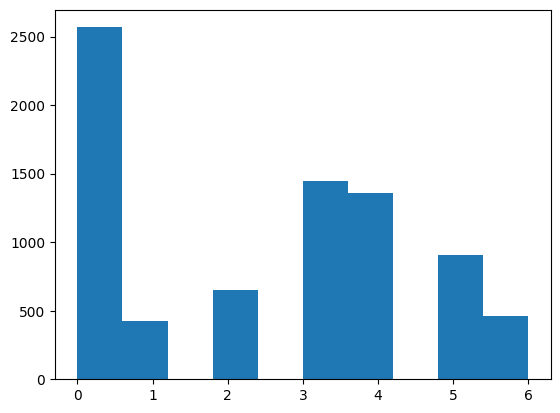

In [21]:
plt.hist(train_set.query('country_id=="FMW"')['label'].values)